# Función Auxiliar (No Modificar)

In [2]:
import pandas as pd
import numpy as np
import hashlib

def generar_seed(nombre_alumno):
    """
    Genera un número entero a partir del nombre del alumno para usar como semilla.
    """
    # Crear hash md5 del nombre
    hash_object = hashlib.md5(nombre_alumno.encode())
    hash_hex = hash_object.hexdigest()
    # Convertir los primeros 8 dígitos hexadecimales a entero
    seed = int(hash_hex[:8], 16)
    return seed

def generar_dataset_alumno(nombre_alumno, n=3000, filename=None):
    """
    Genera un dataset de coches usado personalizado para un alumno.

    Args:
        nombre_alumno (str): nombre del alumno
        n (int): número de filas
        filename (str): si se proporciona, guarda CSV con este nombre
    Returns:
        pd.DataFrame
    """
    seed = generar_seed(nombre_alumno)
    np.random.seed(seed)

    # Variables numéricas
    engine_size = np.random.choice(np.arange(1.0, 3.6, 0.1), size=n)
    horsepower = (engine_size * 70 + np.random.randint(-15,15,size=n)).astype(int)
    weight = (engine_size * 500 + np.random.randint(-50,50,size=n)).astype(int)
    fuel_consumption = (4 + engine_size*2 + np.random.rand(n)*0.5).round(1)
    age = np.random.randint(0,16,size=n)
    doors = np.random.choice([3,5], size=n)

    # Variables categóricas
    brands = ["Ford","Volkswagen","Toyota","BMW","Renault","Peugeot","Audi","Fiat",
              "Hyundai","Mercedes","Seat","Opel","Volvo","Skoda","Kia"]
    brand = np.random.choice(brands, size=n)

    fuel_type = np.random.choice(["gasoline","diesel","hybrid"], size=n)
    countries = ["Germany","France","Japan","Italy","Spain","Sweden","South Korea","Czech Republic"]
    country = np.random.choice(countries, size=n)

    # Columna constante
    dealer_id = np.ones(n) * 101  # nombre ambiguo, no indicar que es constante

    # Precio aproximado
    price = (2000 + horsepower*80 + engine_size*1000 - age*500 + np.random.randint(-1000,1000,size=n)).astype(int)

    # Crear DataFrame
    df = pd.DataFrame({
        "engine_size": engine_size,
        "horsepower": horsepower,
        "weight": weight,
        "fuel_consumption": fuel_consumption,
        "age": age,
        "doors": doors,
        "brand": brand,
        "fuel_type": fuel_type,
        "country": country,
        "dealer_id": dealer_id,
        "price": price
    })

    # Introducir nulos aleatorios (~5%)
    n_nulos = n // 20
    df.loc[np.random.choice(df.index, size=n_nulos, replace=False), "horsepower"] = np.nan
    df.loc[np.random.choice(df.index, size=n_nulos, replace=False), "fuel_consumption"] = np.nan

    # Guardar CSV si se proporciona filename
    if filename:
        df.to_csv(filename, index=False)
        print(f"CSV generado para {nombre_alumno}: {filename}")

    return df


# 📘 EXAMEN: PROGRAMACIÓN DE INTELIGENCIA ARTIFICIAL

**Duración:** 110 minutos  
**Entorno:** Google Colab  
**Librerías permitidas:** numpy, pandas, matplotlib, scikit-learn

🚫 No se permite el uso de otras librerías de ML ni AutoML.

## Objetivo
Desarrollar una aplicación de IA que prediga el precio de vehículos de segunda mano a partir de sus características.
El alumno deberá analizar los datos, decidir qué transformaciones aplicar, entrenar un modelo de regresión y evaluar su rendimiento, justificando cada decisión.

In [3]:
nombre_alumno = "Juan Sebastián Vélez Arias"

In [4]:
generar_dataset_alumno(nombre_alumno, n=3000, filename="used_cars_fp.csv")

CSV generado para Juan Sebastián Vélez Arias: used_cars_fp.csv


,engine_size,horsepower,weight,fuel_consumption,age,doors,brand,fuel_type,country,dealer_id,price
0,2.1,141.0,1002,8.6,8,3,Hyundai,hybrid,Spain,101.0,12225
1,2.3,171.0,1166,8.9,3,5,Seat,hybrid,Czech Republic,101.0,16384
2,2.0,137.0,1020,8.4,5,5,Renault,hybrid,Spain,101.0,12927
3,1.6,116.0,814,7.6,3,3,Opel,diesel,Germany,101.0,11433
4,2.9,196.0,1417,10.2,12,5,Seat,gasoline,Sweden,101.0,15268
...,...,...,...,...,...,...,...,...,...,...,...
2995,3.5,231.0,1789,11.4,1,5,BMW,hybrid,Spain,101.0,24171
2996,3.1,218.0,1500,10.2,4,3,Audi,diesel,Italy,101.0,20696
2997,3.1,220.0,1513,10.5,2,3,Kia,hybrid,Germany,101.0,22195
2998,1.6,110.0,779,7.5,12,3,Mercedes,hybrid,Germany,101.0,5703


## 🔹 CELDA 1 – Importación de librerías

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

## 🔹 CELDA 2 – Carga del dataset (5 puntos)

Tareas:
1. Cargar el dataset `used_cars_fp.csv` en un DataFrame llamado `df`
2. Mostrar las 5 primeras filas
3. Mostrar información general del dataset

In [7]:
# TODO: Cargar el dataset
df = pd.read_csv("used_cars_fp.csv")

In [8]:
df

,engine_size,horsepower,weight,fuel_consumption,age,doors,brand,fuel_type,country,dealer_id,price
0,2.1,141.0,1002,8.6,8,3,Hyundai,hybrid,Spain,101.0,12225
1,2.3,171.0,1166,8.9,3,5,Seat,hybrid,Czech Republic,101.0,16384
2,2.0,137.0,1020,8.4,5,5,Renault,hybrid,Spain,101.0,12927
3,1.6,116.0,814,7.6,3,3,Opel,diesel,Germany,101.0,11433
4,2.9,196.0,1417,10.2,12,5,Seat,gasoline,Sweden,101.0,15268
...,...,...,...,...,...,...,...,...,...,...,...
2995,3.5,231.0,1789,11.4,1,5,BMW,hybrid,Spain,101.0,24171
2996,3.1,218.0,1500,10.2,4,3,Audi,diesel,Italy,101.0,20696
2997,3.1,220.0,1513,10.5,2,3,Kia,hybrid,Germany,101.0,22195
2998,1.6,110.0,779,7.5,12,3,Mercedes,hybrid,Germany,101.0,5703


In [9]:
# TODO: Mostrar las primeras filas
df.head()
# TODO: Mostrar información del dataset
df.info()
df.describe()
df.sort_values(by="price")

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   engine_size       3000 non-null   float64
 1   horsepower        2850 non-null   float64
 2   weight            3000 non-null   int64  
 3   fuel_consumption  2850 non-null   float64
 4   age               3000 non-null   int64  
 5   doors             3000 non-null   int64  
 6   brand             3000 non-null   str    
 7   fuel_type         3000 non-null   str    
 8   country           3000 non-null   str    
 9   dealer_id         3000 non-null   float64
 10  price             3000 non-null   int64  
dtypes: float64(4), int64(4), str(3)
memory usage: 257.9 KB


,engine_size,horsepower,weight,fuel_consumption,age,doors,brand,fuel_type,country,dealer_id,price
822,1.0,61.0,460,6.5,14,3,Peugeot,diesel,Japan,101.0,90
1176,1.0,67.0,509,6.3,15,5,Peugeot,hybrid,Spain,101.0,96
49,1.1,65.0,550,6.5,15,3,Skoda,hybrid,Sweden,101.0,174
505,1.1,68.0,500,6.5,15,3,Hyundai,hybrid,Spain,101.0,184
446,1.0,58.0,513,6.1,13,3,Fiat,hybrid,Japan,101.0,270
...,...,...,...,...,...,...,...,...,...,...,...
356,3.5,253.0,1727,11.3,1,3,Seat,diesel,Sweden,101.0,25691
857,3.5,256.0,1795,11.3,2,5,Ford,gasoline,France,101.0,25709
2541,3.5,244.0,1710,11.3,0,3,Opel,hybrid,Sweden,101.0,25827
1309,3.4,249.0,1724,11.0,0,5,Toyota,hybrid,South Korea,101.0,26071


## 🔹 CELDA 3 – Análisis exploratorio de datos (15 puntos)

Tareas:
1. Identificar columnas numéricas y categóricas.
2. Detectar valores nulos y columnas que podrían no aportar información.
3. Eliminar columnas que no sean útiles.

Incluye comentarios justificando tus decisiones.

In [ ]:
# TODO: Identificar columnas numéricas y categóricas


In [14]:
# TODO: Detectar valores nulos
print(df.isna().sum()) # conteo de nulso por cada columna 
print(df.isna().mean() * 100 ) # porcentaje de nulos 
# Niveles de limpieza 

engine_size           0
horsepower          150
weight                0
fuel_consumption    150
age                   0
doors                 0
brand                 0
fuel_type             0
country               0
dealer_id             0
price                 0
dtype: int64
engine_size         0.0
horsepower          5.0
weight              0.0
fuel_consumption    5.0
age                 0.0
doors               0.0
brand               0.0
fuel_type           0.0
country             0.0
dealer_id           0.0
price               0.0
dtype: float64


In [34]:
# Rellenar con le media 
df.prueba = df.copy()
print(df['engine_size'].min())
print(df['horsepower'].min())
# Esto crea exactamente lo que dibujaste: una lista de valores por grupo
print(df.prueba.groupby('engine_size')['horsepower'].apply(list))
print(df.prueba.groupby('engine_size')['horsepower'].mean())
print(df.group.groupby('engine_size').groups)

#df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())
#df['fuel_consumption'] = df['fuel_consumption'].fillna(df['fuel_consumption'].mean)
# Rellenar con la media con el mismo tamaño del motor 
#df['horsepower'] = df['horsepower'].fillna(df.groupby('engine_size')['horsepower'].transform('mean'))
#df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

1.0
55.0
engine_size
1.0    [74.0, 71.0, 58.0, 69.0, 76.0, 59.0, 77.0, 72....
1.1    [65.0, 75.0, 82.0, 69.0, 81.0, 78.0, 77.0, 77....
1.2    [80.0, 87.0, 84.0, 91.0, 96.0, 93.0, 87.0, 93....
1.3    [99.0, 103.0, 88.0, 82.0, 95.0, 81.0, 84.0, na...
1.4    [100.0, 87.0, 97.0, 104.0, 87.0, 91.0, 97.0, 8...
1.5    [109.0, 117.0, 104.0, 117.0, 116.0, 90.0, 116....
1.6    [116.0, 110.0, 120.0, 103.0, 100.0, 107.0, 105...
1.7    [115.0, 104.0, 113.0, 108.0, 105.0, 114.0, 111...
1.8    [129.0, 125.0, 120.0, 119.0, 117.0, 128.0, 113...
1.9    [134.0, 132.0, 126.0, nan, 124.0, 120.0, 119.0...
2.0    [137.0, 151.0, 125.0, 134.0, 130.0, 130.0, 139...
2.1    [141.0, 139.0, 158.0, 137.0, 133.0, 136.0, 133...
2.2    [167.0, 168.0, 143.0, 155.0, nan, 145.0, 159.0...
2.3    [171.0, 164.0, 157.0, 166.0, 169.0, 155.0, 148...
2.4    [174.0, 176.0, 173.0, 162.0, 158.0, 156.0, 169...
2.5    [179.0, nan, 162.0, 187.0, 186.0, 177.0, 179.0...
2.6    [190.0, 194.0, 191.0, 196.0, 192.0, 196.0, 190...
2.7    [17

AttributeError: 'DataFrame' object has no attribute 'group'

In [ ]:
# TODO: Detectar columnas no informativas

In [10]:
# TODO: Eliminar columnas no útiles

## 🔹 CELDA 4 – Visualización de datos (10 puntos)

Tareas:
Explora visualmente la relación entre variables y el precio de los vehículos.
Realiza al menos dos gráficos utilizando solo matplotlib, incluyendo:

1. Scatter plot de horsepower vs price

2. Boxplot simple de brand vs price

Incluye comentarios breves explicando lo que observas y cómo podría afectar al modelo de regresión.

In [62]:
# TODO: Crear un gráfico con matplotlib
plt.close('all')
grafico = pd.Series(df['price'])
plt.show()

0       12225
1       16384
2       12927
3       11433
4       15268
        ...  
2995    24171
2996    20696
2997    22195
2998     5703
2999    19418
Name: price, Length: 3000, dtype: int64


TypeError: The first argument to axis() must be an iterable of the form [xmin, xmax, ymin, ymax]

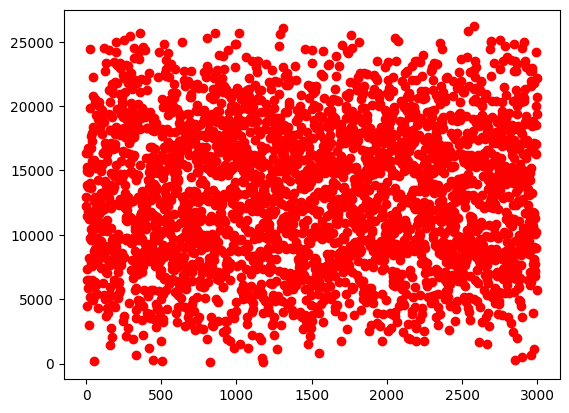

In [79]:
precio = df['price']
potencia = df['horsepower']
print(precio)
plt.plot(precio, 'ro')
plt.axis(df['brand'])

## 🔹 CELDA 5 – División del conjunto de datos (5 puntos)

Dividir en entrenamiento (80%) y test (20%).

In [82]:
# TODO: Dividir los datos en train y testa
train_data = 0
test_data = 0

## 🔹 CELDA 6 – Flujo de procesamiento(imputación,escalado,codificación) de datos (20 puntos)

Tareas:
1. Separar variables predictoras (`X`) y objetivo (`y`).
2. Crear flujos para:
   - Variables numéricas: imputación (media) + estandarización
   - Variables categóricas: imputación (valor más frecuente) + codificación



In [ ]:
# TODO: Separar X e y
# TODO: Definir columnas numéricas y categóricas
# TODO: Crear pipelines de preprocesamiento
# TODO: Crear el ColumnTransformer

## 🔹 CELDA 7 – Optimización del conjunto de variables (10 puntos)

Algunas variables numéricas pueden estar fuertemente correlacionadas entre sí, generando información redundante.
Analiza la relación entre las variables y decide cómo simplificar el conjunto de variables para el modelo.
Ajusta tu selección de variables o combinaciones de manera que mantengas al menos un 80% de la variabilidad de los datos.
Justifica tu elección con un gráfico o tabla que muestre las relaciones y explica cómo afectaría al modelo.

In [ ]:
# TODO: Aplicar reducción de dimensionalidad si lo consideras
# TODO: Justificar la decisión

## 🔹 CELDA 8 – Modelo (20 puntos)

El objetivo es predecir el precio de un vehículo a partir de sus características.
Decide qué método o algoritmo utilizarías para estimar un valor numérico continuo y justifica tu elección.
Integra este método en un flujo de procesamiento que transforme los datos y produzca la predicción.

In [ ]:
# TODO: Crear pipeline completo con regresión
# TODO: Entrenar el modelo

## 🔹 CELDA 9 – Evaluación del modelo (10 puntos)

Evaluar el rendimiento en test utilizando las métricas que mejor apliquen.

In [ ]:
# TODO: Realizar predicciones sobre test
# TODO: Calcular métricas


## 🔹 CELDA 10 – Predicción de nuevos datos (10 puntos)

Se proporciona un vehículo nuevo:

```python
nuevo_vehiculo = pd.DataFrame([{
    "engine_size": 2.0,
    "horsepower": 150,
    "weight": 1300,
    "fuel_consumption": 6.5,
    "age": 3,
    "doors": 5,
    "brand": "Toyota",
    "fuel_type": "hybrid",
    "country": "Japan"
}])
```
Predecir el precio utilizando el modelo entrenado.

In [ ]:
# TODO: Predecir el precio del nuevo vehículo

## Observaciones
- El alumno debe razonar y justificar cada decisión, no solo ejecutar código.

Consultas:

- Diferenciar  categoría precios:
1. Chatarra < 500 euros (precios outliers )
2. Economico 500 a 1000 euros
3. Gamma media de 1000 a 10000 euros
4. Precio salida 10000 a 20000 euros
5. Buena gamma > 20000 euros
- Coches de x marca
- Coche mas caro de x marca, coches mas baratos de x marca
- precio medio por marca

Precio limite, cuales son los limites?